<h2 align="center">Exploratory Data Analysis</h2>

In [2]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleaning the data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Most Demanding Jobs in India

In [14]:
# creating dataframe for jobs available in India
df_IN = df[df['job_country']=='India'].copy()

# sorting by larger to smaller count of distinct job titles
df_IN_jobs = df_IN['job_title_short'].value_counts().to_frame()
df_IN_jobs

,count
job_title_short,
Data Engineer,19062
Data Scientist,13279
Data Analyst,6121
Senior Data Engineer,4353
Senior Data Scientist,2486
Business Analyst,1887
Software Engineer,1795
Senior Data Analyst,1083
Machine Learning Engineer,671


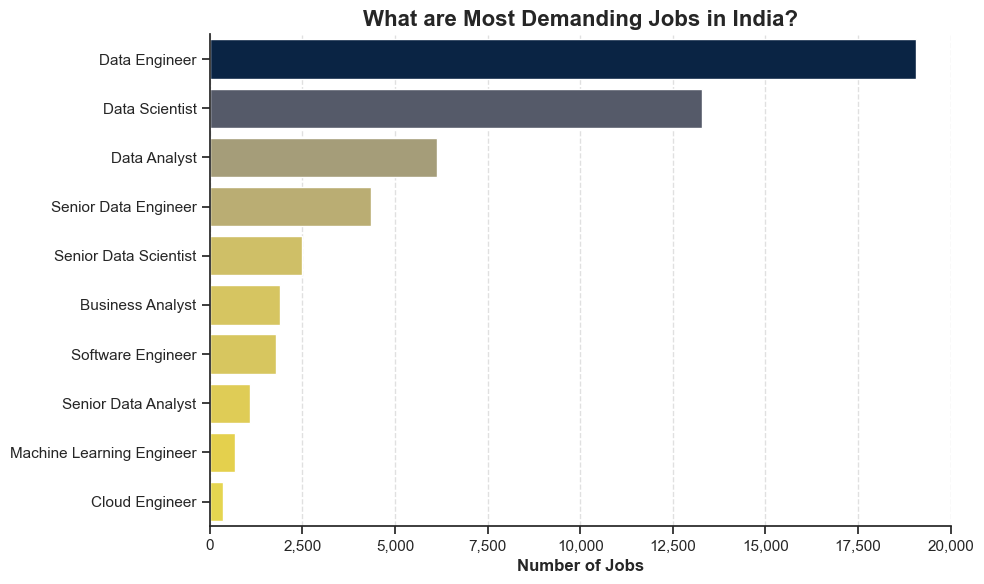

In [15]:
# Final Plotting
from matplotlib.ticker import StrMethodFormatter
sns.set_theme(style='ticks')

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df_IN_jobs,x='count',y='job_title_short', hue='count',palette="cividis_r",legend=False)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title("What are Most Demanding Jobs in India?", fontsize=16, weight="bold")
plt.xlabel("Number of Jobs", fontsize=12,weight="bold")
plt.ylabel('')
plt.grid(axis="x", linestyle="--", alpha=0.6)
sns.despine()

# Adjust layout
plt.tight_layout()

plt.show()

# Top companies providing jobs in india

In [22]:
# now lets calculate Top companies providing jobs in india

df_IN_company = df_IN['company_name'].value_counts().to_frame().head(20)

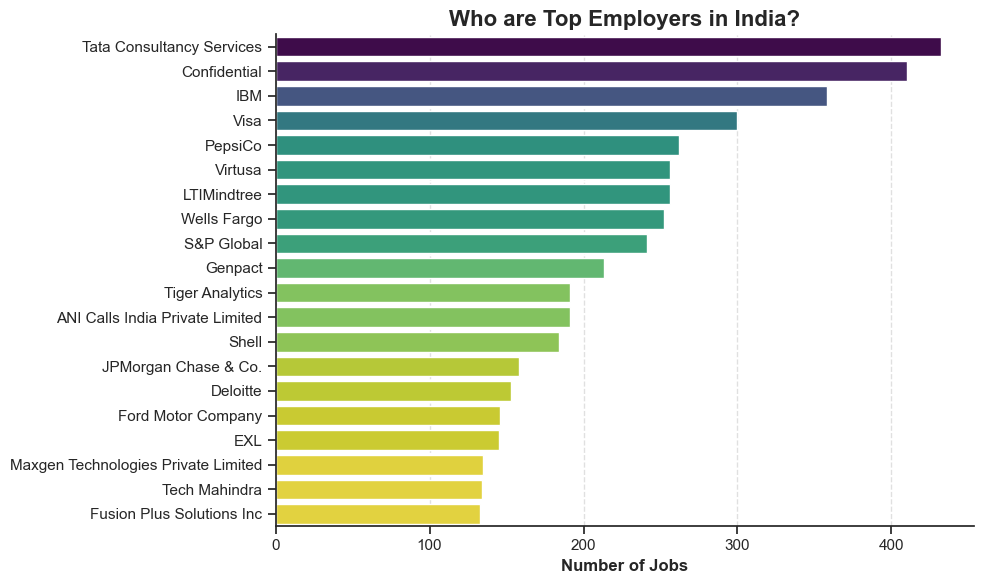

In [31]:
# Final Plotting
from matplotlib.ticker import StrMethodFormatter
sns.set_theme(style='ticks')

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df_IN_company,x='count',y='company_name', hue='count',palette="viridis_r",legend=False)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title("Who are Top Employers in India?", fontsize=16, weight="bold")
plt.xlabel("Number of Jobs", fontsize=12,weight="bold")
plt.ylabel('')
plt.grid(axis="x", linestyle="--", alpha=0.6)
sns.despine()

# Adjust layout
plt.tight_layout()

plt.show()

# Top companies Hiring for 'Data Engineers' in India

In [ ]:
# Top companies providing jobs for Data Engineers in india
df_IN_DE = df[(df['job_country']=='India')&(df['job_title_short']=='Data Engineer')]

# creating dataframe by numbers of hiring by companies
df_IN_DE_company = df_IN_DE['company_name'].value_counts().to_frame().head(10)

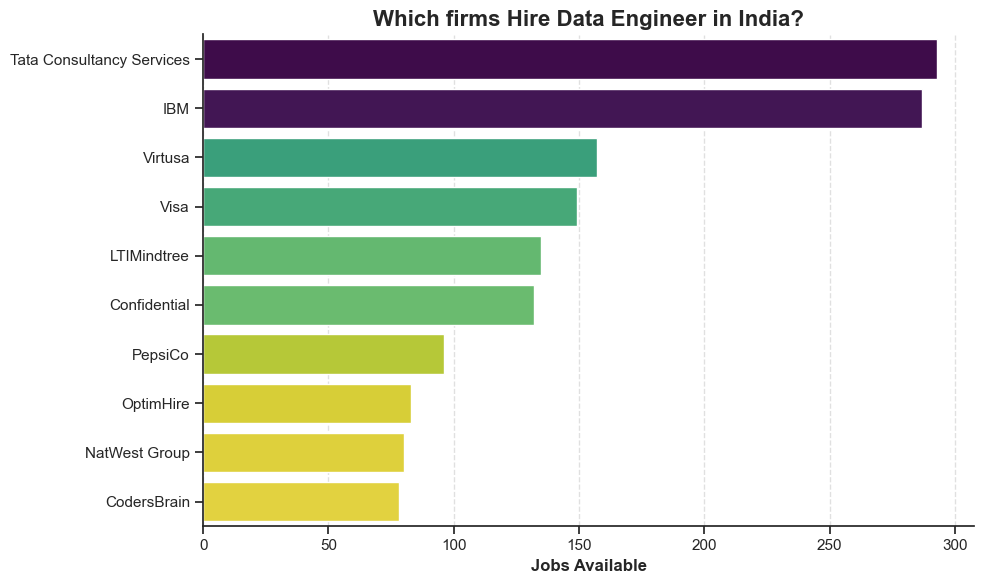

In [77]:
# Final Plotting
from matplotlib.ticker import StrMethodFormatter
sns.set_theme(style='ticks')

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df_IN_DE_company,x='count',y='company_name', hue='count',palette="viridis_r",legend=False)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title("Which firms Hire Data Engineer in India?", fontsize=16, weight="bold")
plt.xlabel("Jobs Available", fontsize=12,weight="bold")
plt.ylabel('')
plt.grid(axis="x", linestyle="--", alpha=0.6)
sns.despine()

# Adjust layout
plt.tight_layout()

plt.show()

# Top Plateforms for Job Seekers in India

In [ ]:
# lets find on which plateforms most jobs are posted
df_plateform = df_IN['job_via'].value_counts().to_frame().head(10).copy()

# Removing 'via'
df_plateform.index = df_plateform.index.str.replace('via ', '', regex=False)

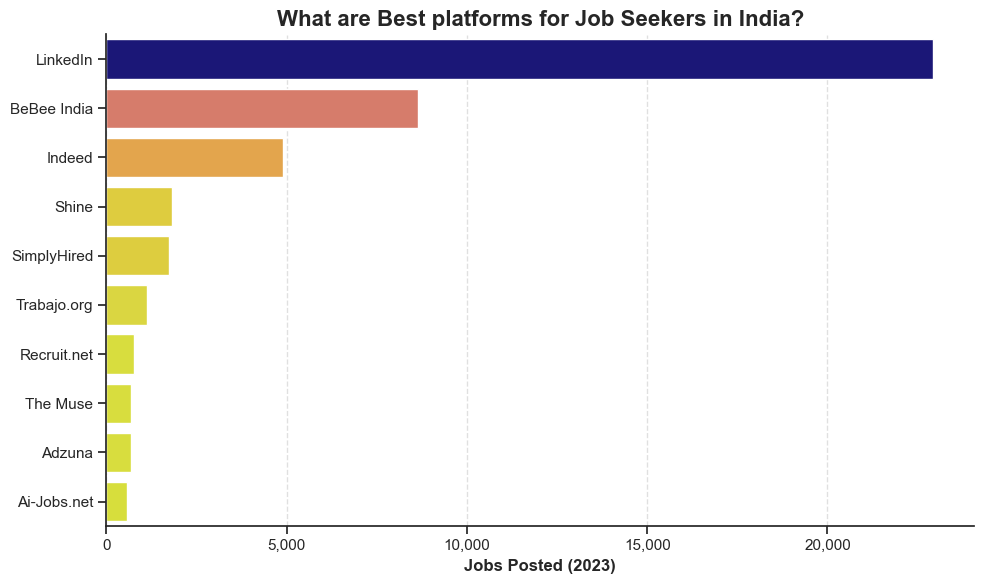

In [104]:
# Final Plotting
from matplotlib.ticker import StrMethodFormatter
sns.set_theme(style='ticks')

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df_plateform,x='count',y='job_via', hue='count',palette="plasma_r",legend=False)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title("What are Best platforms for Job Seekers in India?", fontsize=16, weight="bold")
plt.xlabel("Jobs Posted (2023)", fontsize=12,weight="bold")
plt.ylabel('')
plt.grid(axis="x", linestyle="--", alpha=0.6)
sns.despine()

# Adjust layout
plt.tight_layout()

plt.show()

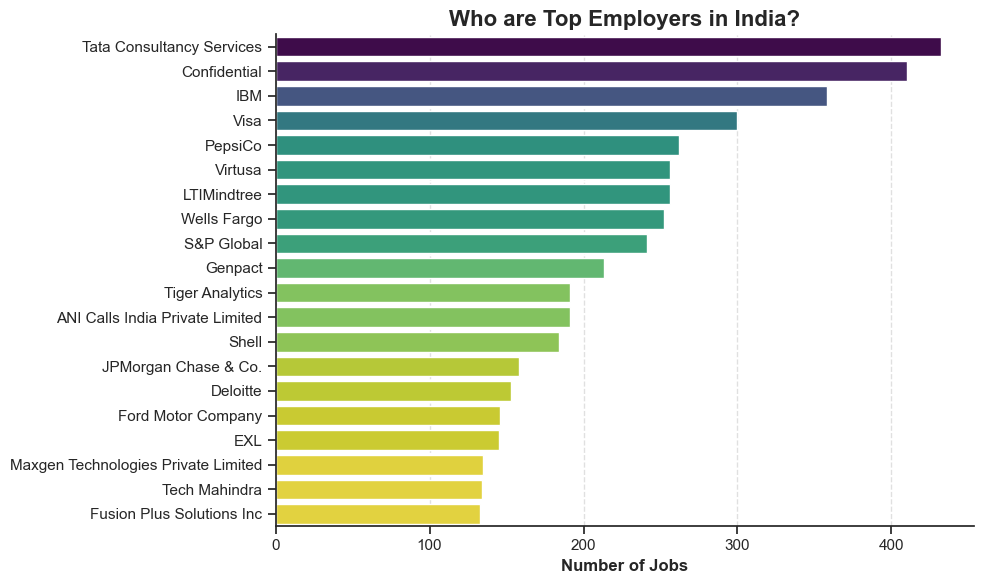

In [78]:
# Final Plotting
from matplotlib.ticker import StrMethodFormatter
sns.set_theme(style='ticks')

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df_IN_company,x='count',y='company_name', hue='count',palette="viridis_r",legend=False)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title("Who are Top Employers in India?", fontsize=16, weight="bold")
plt.xlabel("Number of Jobs", fontsize=12,weight="bold")
plt.ylabel('')
plt.grid(axis="x", linestyle="--", alpha=0.6)
sns.despine()

# Adjust layout
plt.tight_layout()

plt.show()

# Pie Chart Visualization (India)

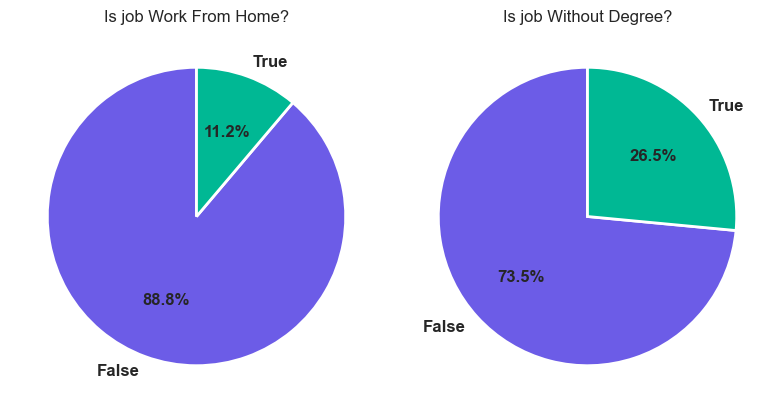

In [63]:
# Assigning name by providing column names

dict_IN = {
    'job_work_from_home': 'Is job Work From Home?',
    'job_no_degree_mention': 'Is job Without Degree?'
}
    
# creating subplots
fig, ax = plt.subplots(1,2, figsize=(8,6))

# generatin titles
for i, (column, title) in enumerate(dict_IN.items()):
    ax[i].pie(df_IN[column].value_counts(), labels=[False, True], autopct='%1.1f%%', startangle=90,
              colors=['#6C5CE7','#00B894'],
              wedgeprops={'edgecolor': 'white', 'linewidth': 2},
              textprops={'fontsize': 12, 'weight': 'bold'})
    
    ax[i].set_title(title)

plt.tight_layout()
plt.show()

In [121]:
# lets find out job types as well
df_IN_type = df_IN['job_schedule_type'].value_counts().to_frame().head(4).copy()

In [123]:
df_IN_type

,count
job_schedule_type,
Full-time,48335
Contractor,1121
Part-time,543
Internship,377


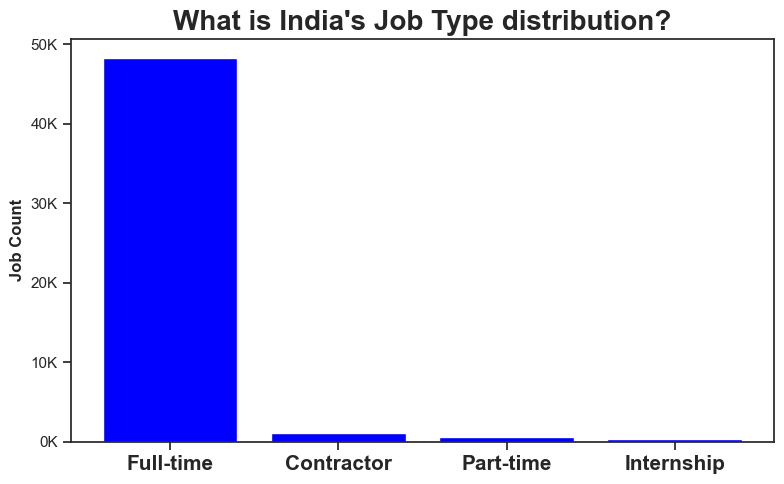

In [177]:
from cProfile import label

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))

plt.bar(
    df_IN_type.index,
    df_IN_type['count'],
    color='Blue'
)

plt.title("What is India's Job Type distribution?", fontsize=20, weight='bold')
plt.xlabel("")
plt.ylabel("Job Count",weight='bold')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1000)}K')
)

plt.xticks(fontsize=15,weight='bold')
plt.tight_layout()
plt.show()

# Top countries by no. of jobs available

In [143]:
# Now lets calculate Top countries by no. of jobs available
df_country = df['job_country'].value_counts().to_frame().head(10)

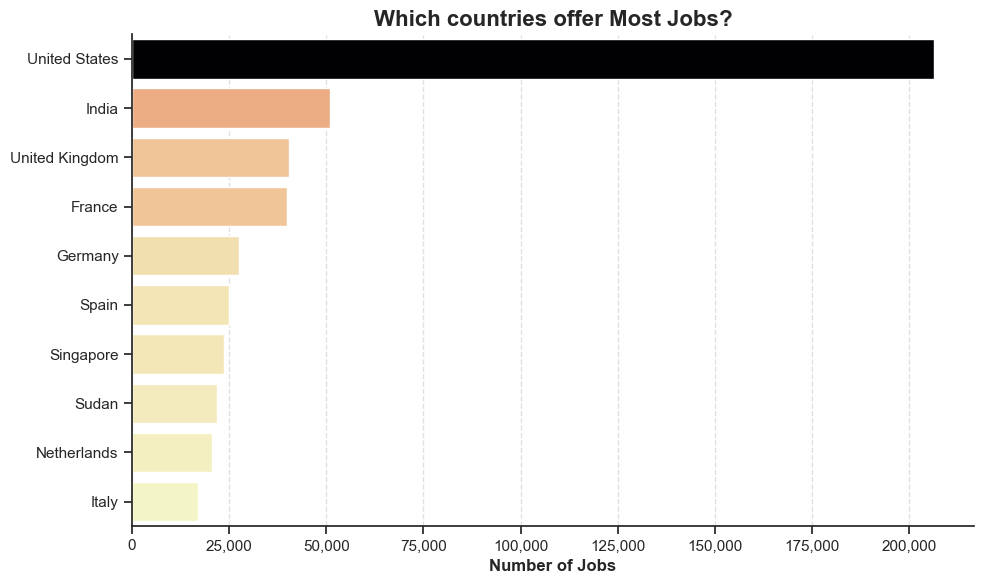

In [65]:
# lets plot the same

# Final Plotting
from matplotlib.ticker import StrMethodFormatter
sns.set_theme(style='ticks')

plt.figure(figsize=(10,6))

ax = sns.barplot(data=df_country,x='count',y='job_country', hue='count',palette="magma_r",legend=False)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title("Which countries offer Most Jobs?", fontsize=16, weight="bold")
plt.xlabel("Number of Jobs", fontsize=12,weight="bold")
plt.ylabel('')
plt.grid(axis="x", linestyle="--", alpha=0.6)
sns.despine()

# Adjust layout
plt.tight_layout()

plt.show()